In [1]:
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from nltk.stem import PorterStemmer

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sujoy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sujoy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
import time

In [ ]:
def convert_likes(column):
    if column.endswith('K'):
        return float(column[:-1]) * 1_000  
    elif column.endswith('M'):
        return float(column[:-1]) * 1_000_000  
    else:
        return float(column)  

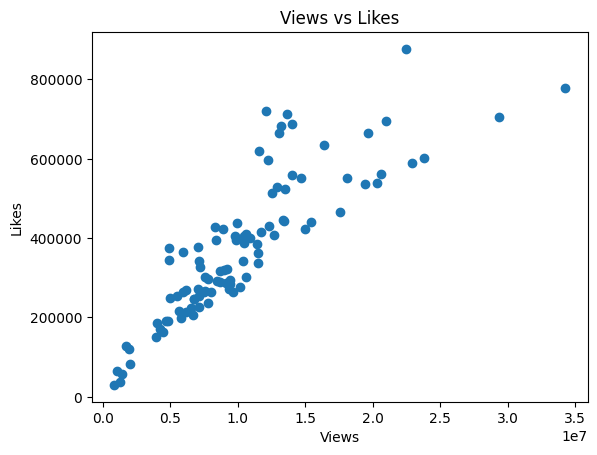

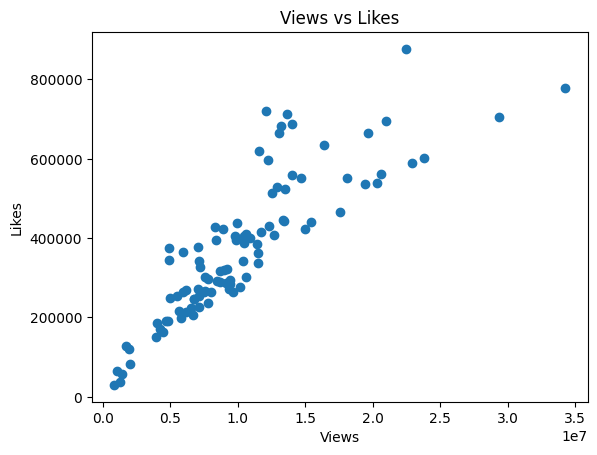

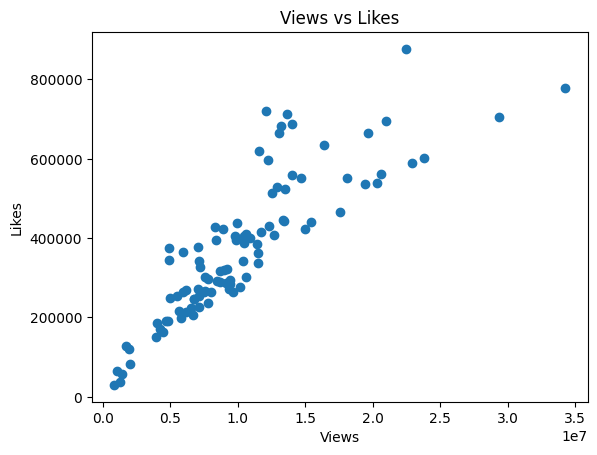

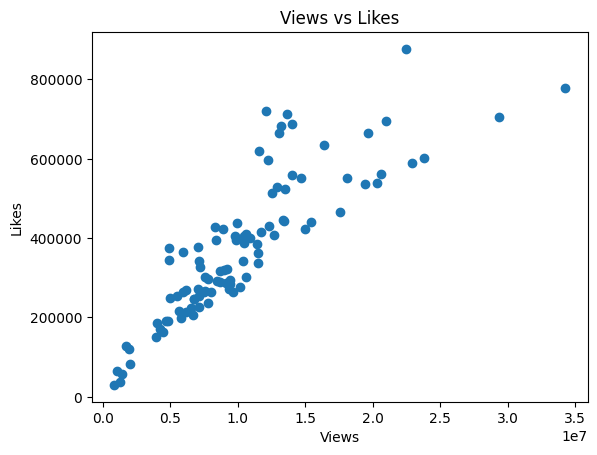

KeyboardInterrupt: 

In [24]:
for _ in range(100):
    # Load the JSON data
    dataframe = pd.read_json(r"D:/YouTube-Likes-predictor/kzg.json")

    # Normalize the 'videos' field in the JSON
    dataframe = pd.json_normalize(dataframe['videos'])
    dataframe['likes'] = dataframe['likes'].apply(convert_likes)
    dataframe['views'] = dataframe['views'].str.replace(',', '').astype(int)
    import matplotlib.pyplot as plt
    plt.scatter(x=dataframe['views'], y=dataframe['likes'])
    plt.xlabel("Views")
    plt.ylabel("Likes")
    plt.title("Views vs Likes")
    plt.show()
    time.sleep(2)

In [14]:
df=dataframe

In [15]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=100)

# Fit and transform the video titles
tfidf_matrix = tfidf_vectorizer.fit_transform(df['video title'])

# Convert TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 2: Feature Engineering - Extract word count from titles
df['word_count'] = df['video title'].apply(lambda x: len(x.split()))

# Combine the new features with the TF-IDF representation
features_df = pd.concat([df[['word_count']], tfidf_df], axis=1)


In [16]:
features_df

,word_count,10,actually,alien,aliens,allergies,angry,ant,awesome,beat,...,star,talk,time,universe,video,virus,war,way,weapon,world
0,6,0.000000,0.0,0.0,1.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,7,0.000000,0.0,0.0,0.0,0.73945,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,6,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.673211
3,7,0.613401,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.558453,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,7,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,10,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
63,10,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.562924,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
64,8,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
65,7,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Step 3: Define Target Variables (Likes & Views)
targets = ['likes', 'views']

# Store predictions
predictions = {}

for target in targets:
    # Splitting data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(features_df, df[target], test_size=0.2, random_state=42)

    # Initialize and train a Random Forest Regressor
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    predictions[target] = {'model': model, 'mae': mae, 'r2': r2, 'predictions': y_pred}

# Display the evaluation metrics
evaluation_df = pd.DataFrame({
    "Target": ["Likes", "Views"],
    "Mean Absolute Error": [predictions['likes']['mae'], predictions['views']['mae']],
    "R² Score": [predictions['likes']['r2'], predictions['views']['r2']]
})


In [18]:
# Step 1: Extract keywords using CountVectorizer (Bag-of-Words)
vectorizer = CountVectorizer(stop_words='english', max_features=20)  # Extract top 20 keywords
keywords_matrix = vectorizer.fit_transform(df['video title'])

# Convert to DataFrame
keywords_df = pd.DataFrame(keywords_matrix.toarray(), columns=vectorizer.get_feature_names_out())


In [19]:
combined_df = pd.concat([features_df, keywords_df], axis=1)

In [20]:
combined_df

,word_count,10,actually,alien,aliens,allergies,angry,ant,awesome,beat,...,inside,internet,life,literally,make,nuclear,time,universe,virus,war
0,6,0.000000,0.0,0.0,1.0,0.00000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,7,0.000000,0.0,0.0,0.0,0.73945,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,6,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,7,0.613401,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,7,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,10,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
63,10,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
64,8,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
65,7,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
